# Lab 5.2: PyTorch Lightning

**Part of the Iceland ML Course: Sentinel-2 Classification Project**

This notebook demonstrates training a classifier for remote sensing land cover classification using PyTorch Lightning.

---

## Project Context

**Inputs (From Lab 3.1):**
- Sentinel-2 patches (10 spectral bands)
- CORINE labels (12 land cover classes)
- NPZ format: combined_training_data.npz (**224x224 patches**)

**What You'll Do:**
- Build and train a CNN-based classifier
- Separate model and data logic using PyTorch-Lightning
- Organize data into PyTorch-Lightning data modules
- Generate model checkpoints for evaluation

**Output:**
- Trained model weights
- Training logs and validation metrics

## Setup and Dependencies

In [25]:
import os

from pathlib import Path

import lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
    WeightedRandomSampler,
    random_split,
)
from torchvision.transforms import v2 as T
import numpy as np

from collections.abc import Mapping
from typing import Any

In [2]:
USER = os.getenv("USER")
SCRATCH = os.getenv("SCRATCH")

DATA_ROOT = Path(f"{SCRATCH}/{USER}/data")
TRAINING_DATA_DIR = DATA_ROOT / "training_data"

assert TRAINING_DATA_DIR.exists(), TRAINING_DATA_DIR

%matplotlib inline
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
CORINE_CLASSES = {
    # Artificial surfaces (1-11)
    1: "Continuous urban fabric",
    2: "Discontinuous urban fabric",
    3: "Industrial or commercial units",
    4: "Road and rail networks",
    5: "Port areas",
    6: "Airports",
    7: "Mineral extraction sites",
    8: "Dump sites",
    9: "Construction sites",
    10: "Green urban areas",
    11: "Sport and leisure facilities",
    # Agricultural areas (12-22)
    12: "Non-irrigated arable land",
    13: "Permanently irrigated land",
    14: "Rice fields",
    15: "Vineyards",
    16: "Fruit trees and berry plantations",
    17: "Olive groves",
    18: "Pastures",
    19: "Annual crops with permanent crops",
    20: "Complex cultivation patterns",
    21: "Agriculture with natural vegetation",
    22: "Agro-forestry areas",
    # Forest and semi-natural areas (23-34)
    23: "Broad-leaved forest",
    24: "Coniferous forest",
    25: "Mixed forest",
    26: "Natural grasslands",
    27: "Moors and heathland",
    28: "Sclerophyllous vegetation",
    29: "Transitional woodland-shrub",
    30: "Beaches, dunes, sands",
    31: "Bare rocks",
    32: "Sparsely vegetated areas",
    33: "Burnt areas",
    34: "Glaciers and perpetual snow",
    # Wetlands (35-39)
    35: "Inland marshes",
    36: "Peat bogs",
    37: "Salt marshes",
    38: "Salines",
    39: "Intertidal flats",
    # Water bodies (40-44)
    40: "Water courses",
    41: "Water bodies",
    42: "Coastal lagoons",
    43: "Estuaries",
    44: "Sea and ocean",
    48: "No data",
}

# Color mapping for visualization
CORINE_COLORS = {
    1: "#E6004D",
    2: "#FF0000",
    3: "#CC4DF2",
    4: "#CC0000",
    5: "#E6CCCC",
    6: "#E6CCE6",
    7: "#A600CC",
    8: "#A64DCC",
    9: "#FF4DFF",
    10: "#FFA6FF",
    11: "#FFE6FF",
    12: "#FFFFA8",
    13: "#FFFF00",
    14: "#E6E600",
    15: "#E68000",
    16: "#F2A64D",
    17: "#E6A600",
    18: "#E6E64D",
    19: "#FFE6A6",
    20: "#FFE64D",
    21: "#E6CC4D",
    22: "#F2CCA6",
    23: "#80FF00",
    24: "#00A600",
    25: "#4DFF00",
    26: "#CCF24D",
    27: "#A6FF80",
    28: "#A6E64D",
    29: "#A6F200",
    30: "#E6E6E6",
    31: "#CCCCCC",
    32: "#CCFFCC",
    33: "#000000",
    34: "#A6E6CC",
    35: "#A6A6FF",
    36: "#4D4DFF",
    37: "#CCCCFF",
    38: "#E6E6FF",
    39: "#A6A6E6",
    40: "#00CCF2",
    41: "#80F2E6",
    42: "#00FFA6",
    43: "#A6FFE6",
    44: "#E6F2FF",
}

print(f"✓ Defined {len(CORINE_CLASSES)} CORINE land cover classes")

✓ Defined 45 CORINE land cover classes


## Custom Dataset Class

Create custom PyTorch `Dataset` and `Subset` classes for loading and splitting Sentinel-2 patches.

In [4]:
# Utils
def _parse_npz_file(file_path):
    return np.load(file_path).values()


def get_class_distribution(dataset):
    distribution = {
        label.item(): count.item()
        for label, count in zip(*dataset.labels.unique(return_counts=True))
    }
    sorted_distribution = {
        k: v
        for k, v in sorted(distribution.items(), key=lambda item: item[1], reverse=True)
    }

    return sorted_distribution

In [5]:
class CorineDataset(Dataset):
    """
    Custom Dataset for remote sensing data.

    Parameters:
    -----------
    data : torch.Tensor
        Feature data (n_samples, n_channels, patch_height, patch_width)
    labels : torch.Tensor
        Target labels (n_samples,)
    """

    def __init__(self, data, labels):

        self.original_labels = labels
        self.original_unique_labels = self.original_labels.unique()
        self.label_mapping = {
            lbl.item(): i for i, lbl in enumerate(self.original_unique_labels)
        }
        self.reverse_label_mapping = {
            i: lbl.item() for i, lbl in enumerate(self.original_unique_labels)
        }

        self.data = data
        self.labels = torch.tensor(
            [self.label_mapping[lbl.item()] for lbl in labels]
        ).type_as(self.original_labels)
        self.unique_labels = self.labels.unique()

        super().__init__()

    def drop_labels(self, blacklist, use_original=True):
        if use_original:
            blacklist = [self.reverse_label_mapping[label] for label in blacklist]
        mask = ~torch.isin(self.original_labels, torch.tensor(blacklist))
        filtered_data, filtered_orig_labels = (
            self.data[mask],
            self.original_labels[mask],
        )

        return CorineDataset(filtered_data, filtered_orig_labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.labels[idx]
        return x, y

In [6]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.labels = self.subset.dataset.labels[self.subset.indices]

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [7]:
file_paths = TRAINING_DATA_DIR.glob("*_data.npz")
patches, labels = map(np.concatenate, zip(*map(_parse_npz_file, file_paths)))

assert patches.shape[0] == labels.shape[0]
print(patches.shape)
print(labels.shape)

(9211, 224, 224, 4)
(9211,)


In [8]:
patch_tensors = torch.tensor(patches).permute(
    0, 3, 1, 2
)  # (N, H, W, C) -> (N, C, H, W)
label_tensors = torch.tensor(labels)
raw_dataset = CorineDataset(data=patch_tensors, labels=label_tensors)

In [9]:
x, y = raw_dataset[42]
print(x.shape, y.shape)

torch.Size([4, 224, 224]) torch.Size([])


In [10]:
class_distribution = get_class_distribution(raw_dataset)

print("Labels distribution")
print(class_distribution)

print("\nMapping")
print(raw_dataset.label_mapping)

Labels distribution
{2: 4918, 3: 1980, 7: 1053, 8: 609, 0: 191, 14: 151, 4: 121, 6: 119, 5: 34, 1: 12, 9: 8, 11: 5, 12: 4, 13: 4, 10: 2}

Mapping
{2: 0, 3: 1, 12: 2, 18: 3, 20: 4, 21: 5, 23: 6, 24: 7, 25: 8, 27: 9, 29: 10, 32: 11, 36: 12, 40: 13, 41: 14}


In [11]:
blacklist = [idx for idx in class_distribution if class_distribution[idx] < 10]
print(blacklist)

[9, 11, 12, 13, 10]


In [12]:
filtered_dataset = raw_dataset.drop_labels(blacklist, use_original=True)

class_distribution = get_class_distribution(filtered_dataset)

print("Labels distribution")
print(class_distribution)

print("\nMapping")
print(filtered_dataset.label_mapping)

Labels distribution
{2: 4918, 3: 1980, 7: 1053, 8: 609, 0: 191, 9: 151, 4: 121, 6: 119, 5: 34, 1: 12}

Mapping
{2: 0, 3: 1, 12: 2, 18: 3, 20: 4, 21: 5, 23: 6, 24: 7, 25: 8, 41: 9}


## Stratified splitting

Implement a stratified splitting mechanism to enforce class distribution across splits. 

A more robust solution is: [StratifiedShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html) from `scikit-learn`.

In [13]:
def get_split(sample_indices, ratios, generator):

    from math import floor

    if len(ratios) == 2:
        _, test_ratio = ratios
        val_ratio = None
    elif len(ratios) == 3:
        _, val_ratio, test_ratio = ratios
    else:
        raise ValueError(
            "Wrong number of ratios provided. Only 2 or 3 ratio values are admitted."
        )

    num_test = max(1, floor(test_ratio * len(sample_indices)))
    num_val = max(1, floor(val_ratio * len(sample_indices))) if val_ratio else 0
    num_train = len(sample_indices) - num_test - num_val

    assert num_train + num_val + num_test == len(sample_indices), (
        "Ratios do not ensure full coverage of samples."
    )

    random_indices = torch.randperm(len(sample_indices), generator=generator)
    slices = [
        slice(0, num_train),
        slice(num_train, num_train + num_val),
        slice(num_train + num_val, num_train + num_val + num_test),
    ]
    train_indices, val_indices, test_indices = [
        sample_indices[random_indices[s]] for s in slices
    ]

    if val_indices.numel() == 0:
        return train_indices, test_indices
    return train_indices, val_indices, test_indices

In [14]:
def make_splits_train_val_test(
    dataset,
    train_frac=0.9,
    val_frac=0.05,
    test_frac=0.05,
    seed=42,
    stratify=True,
):
    """
    Train/Val/Test split with optional stratification.

    Requirements:
      train_frac + val_frac + test_frac == 1.0
    """
    total = train_frac + val_frac + test_frac
    assert abs(total - 1.0) < 1e-6, "train_frac + val_frac + test_frac must be 1.0"

    ratios = [train_frac, val_frac, test_frac]
    generator = torch.Generator().manual_seed(seed)

    if not stratify:
        train_dataset, val_dataset, test_dataset = random_split(
            dataset, ratios, generator=generator
        )
        return train_dataset, val_dataset, test_dataset

    labels = dataset.labels
    class_indices = [
        torch.argwhere(labels == label).flatten() for label in labels.unique()
    ]
    class_splits = [
        get_split(indices, ratios=ratios, generator=generator)
        for indices in class_indices
    ]
    subset_indices = map(torch.cat, zip(*class_splits))

    return [Subset(dataset, index_set) for index_set in subset_indices]

## Without data module

Split dataset and create separate data loaders.

In [15]:
train_dataset, val_dataset, test_dataset = make_splits_train_val_test(
    filtered_dataset, train_frac=0.8, val_frac=0.1, test_frac=0.1, stratify=True
)

In [16]:
print("Subsets summary")
print("=" * 50)

print("\nTraining set")
print("-" * 50)
print(f"# Training samples: {len(train_dataset)}")
train_labels = filtered_dataset.labels[train_dataset.indices]
print(f"# Training labels: {train_labels.unique()}")

print("\nValidation set")
print("-" * 50)
print(f"# Validation samples: {len(val_dataset)}")
val_labels = filtered_dataset.labels[val_dataset.indices]
print(f"# Validation labels: {val_labels.unique()}")

print("\nTest set")
print("-" * 50)
print(f"# Test samples: {len(test_dataset)}")
test_labels = filtered_dataset.labels[test_dataset.indices]
print(f"# Test labels: {test_labels.unique()}")

print("\nMissing classes")
unique_train_labels, unique_val_labels, unique_test_labels = [
    set(labels.unique().tolist()) for labels in (train_labels, val_labels, test_labels)
]
print(f"Val-Train: {unique_val_labels - unique_train_labels}")
print(f"Test-Train: {unique_test_labels - unique_train_labels}")
print(f"Train-Val: {unique_train_labels - unique_val_labels}")
print(f"Train-Test: {unique_train_labels - unique_test_labels}")

Subsets summary

Training set
--------------------------------------------------
# Training samples: 7358
# Training labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)

Validation set
--------------------------------------------------
# Validation samples: 915
# Validation labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)

Test set
--------------------------------------------------
# Test samples: 915
# Test labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)

Missing classes
Val-Train: set()
Test-Train: set()
Train-Val: set()
Train-Test: set()


In [17]:
# --- 5) Sanity check label distribution ---
def label_hist(y_arr, name, topk=10):
    vals, cnts = y_arr.unique(return_counts=True)
    order = torch.argsort(cnts, descending=True)
    print(f"\n{name} label distribution (top {topk}):")
    for v, c in zip(vals[order][:topk], cnts[order][:topk]):
        orig = filtered_dataset.reverse_label_mapping[int(v)]
        print(f"  idx {int(v):2d} (CORINE {orig:2d}): {int(c)}")


label_hist(train_labels, "Train")
label_hist(val_labels, "Val")
label_hist(test_labels, "Test")


Train label distribution (top 10):
  idx  2 (CORINE 12): 3936
  idx  3 (CORINE 18): 1584
  idx  7 (CORINE 24): 843
  idx  8 (CORINE 25): 489
  idx  0 (CORINE  2): 153
  idx  9 (CORINE 41): 121
  idx  4 (CORINE 20): 97
  idx  6 (CORINE 23): 97
  idx  5 (CORINE 21): 28
  idx  1 (CORINE  3): 10

Val label distribution (top 10):
  idx  2 (CORINE 12): 491
  idx  3 (CORINE 18): 198
  idx  7 (CORINE 24): 105
  idx  8 (CORINE 25): 60
  idx  0 (CORINE  2): 19
  idx  9 (CORINE 41): 15
  idx  4 (CORINE 20): 12
  idx  6 (CORINE 23): 11
  idx  5 (CORINE 21): 3
  idx  1 (CORINE  3): 1

Test label distribution (top 10):
  idx  2 (CORINE 12): 491
  idx  3 (CORINE 18): 198
  idx  7 (CORINE 24): 105
  idx  8 (CORINE 25): 60
  idx  0 (CORINE  2): 19
  idx  9 (CORINE 41): 15
  idx  4 (CORINE 20): 12
  idx  6 (CORINE 23): 11
  idx  5 (CORINE 21): 3
  idx  1 (CORINE  3): 1


### Transforms

In [115]:
train_transform = T.Compose(
    [
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),
    ]
)

### Sampler

Implement a weighted random sampler from class-specific weights

In [18]:
train_labels = filtered_dataset.labels[train_dataset.indices]
unique_labels, counts = train_labels.unique(return_counts=True)

class_weights = torch.reciprocal(counts)
weights_dict = {k.item(): v.item() for k, v in zip(unique_labels, class_weights)}
sample_weights = torch.tensor(
    [weights_dict[label.item()] for label in train_labels], dtype=torch.float64
)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

print(unique_labels)
print(weights_dict)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)
{0: 0.006535947788506746, 1: 0.10000000149011612, 2: 0.0002540650311857462, 3: 0.0006313131307251751, 4: 0.010309278033673763, 5: 0.0357142873108387, 6: 0.010309278033673763, 7: 0.001186239649541676, 8: 0.002044989727437496, 9: 0.00826446246355772}


### Data loaders

In [19]:
train_dataloader = DataLoader(
    TransformedSubset(train_dataset, None),
    sampler=weighted_sampler,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

val_dataloader = DataLoader(
    TransformedSubset(val_dataset, None),
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_dataloader = DataLoader(
    TransformedSubset(test_dataset, None),
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0788271].


torch.Size([8, 4, 224, 224]) torch.Size([8])


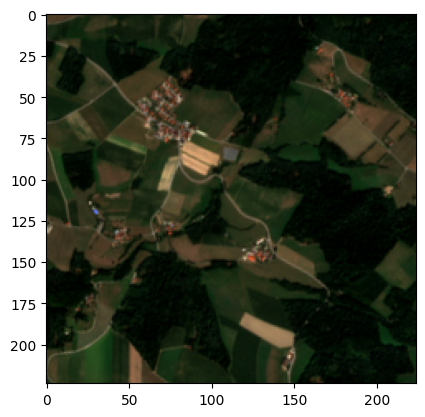

In [20]:
from matplotlib import pyplot as plt

with torch.inference_mode():
    x, y = next(iter(train_dataloader))
    print(x.shape, y.shape)
    gain = 1.5
    rgb = x[0, ...].numpy().transpose(1, 2, 0)
    rgb = np.clip(rgb[:, :, [2, 1, 0]], 0, 1)  # Ensure in [0, 1]

plt.imshow(gain * rgb)
plt.show()

## With data module

Separate data from model and training logic using a `LightningDataModule`

### Config

In [19]:
config = {
    "data": {
        "batch_size": 32,
        "train_ratio": 0.9,
        "val_ratio": 0.05,
        "test_ratio": 0.05,
        "split_strategy": "stratified",
        "sampling_strategy": "weighted",
        "transforms": {"train": None, "val": None},
    },
    "model": {"in_channels": 4, "patch_size": 224},
    "training": {"epochs": 20, "lr": 3e-4},
}

In [16]:
class CorineDataModule(pl.LightningDataModule):
    def __init__(self, dataset: Dataset, cfg: Mapping[str, Any]):
        super().__init__()
        self.dataset = dataset
        self.cfg = cfg

        split_strategy = self.cfg.get("split_strategy", None)
        if not split_strategy:
            print("Could not detect split strategy, defaulting to random splitting.")
            self.stratify = False
        elif split_strategy == "random":
            self.stratify = False
        elif split_strategy == "stratified":
            self.stratify = True
        else:
            raise ValueError(
                f"Unrecognized split strategy detected: '{split_strategy}'. Valid values are: 'random', 'stratified'."
            )

    def setup(self, stage: str):
        train_dataset, val_dataset, test_dataset = make_splits_train_val_test(
            self.dataset,
            train_frac=self.cfg["train_ratio"],
            val_frac=self.cfg["val_ratio"],
            test_frac=self.cfg["test_ratio"],
            stratify=self.stratify,
        )

        if stage == "fit":
            self.train_dataset = TransformedSubset(
                train_dataset, self.cfg["transforms"]["train"]
            )
            self.val_dataset = TransformedSubset(
                val_dataset, self.cfg["transforms"]["val"]
            )

        if stage == "test":
            self.test_dataset = TransformedSubset(
                test_dataset, self.cfg["transforms"]["val"]
            )

    def train_dataloader(self):
        sampling_strategy = self.cfg.get("sampling_strategy", None)
        if not sampling_strategy:
            print("Could not detect sampling strategy, defaulting to random sampling.")
            shuffle = True
            sampler = None
        elif sampling_strategy == "random":
            shuffle = True
            sampler = None
        elif sampling_strategy == "weighted":
            # train_labels = self.dataset.labels[self.train_dataset.subset.indices]
            train_labels = self.train_dataset.labels
            unique_labels, counts = train_labels.unique(return_counts=True)
            class_weights = torch.reciprocal(counts)
            weights_dict = {
                k.item(): v.item() for k, v in zip(unique_labels, class_weights)
            }
            sample_weights = torch.tensor(
                [weights_dict[label.item()] for label in train_labels],
                dtype=torch.float64,
            )

            print(f"Using weighted random sampling with class weights: {weights_dict}")

            shuffle = False
            sampler = WeightedRandomSampler(
                weights=sample_weights,
                num_samples=len(sample_weights),
                replacement=True,
            )
        else:
            raise ValueError(
                f"Unrecognized split strategy detected: '{sampling_strategy}'. Valid values are: 'random', 'weighted'."
            )

        return DataLoader(
            self.train_dataset,
            batch_size=self.cfg["batch_size"],
            shuffle=shuffle,
            sampler=sampler,
            num_workers=2,
            pin_memory=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
        )

In [17]:
datamodule = CorineDataModule(filtered_dataset, cfg=config["data"])

In [19]:
datamodule.setup(stage="fit")
train_dataset = datamodule.train_dataset
val_dataset = datamodule.val_dataset

datamodule.setup(stage="test")
test_dataset = datamodule.test_dataset

print("Subsets summary")
print("=" * 50)

print("\nTraining set")
print("-" * 50)
print(f"# Training samples: {len(train_dataset)}")
# train_labels = filtered_dataset.labels[train_dataset.indices]
train_labels = train_dataset.labels
print(f"# Training labels: {train_labels.unique()}")

print("\nValidation set")
print("-" * 50)
print(f"# Validation samples: {len(val_dataset)}")
# val_labels = filtered_dataset.labels[val_dataset.indices]
val_labels = val_dataset.labels
print(f"# Validation labels: {val_labels.unique()}")

print("\nTest set")
print("-" * 50)
print(f"# Test samples: {len(test_dataset)}")
# test_labels = filtered_dataset.labels[test_dataset.indices]
test_labels = test_dataset.labels
print(f"# Test labels: {test_labels.unique()}")

print("\nMissing classes")
unique_train_labels, unique_val_labels, unique_test_labels = [
    set(labels.unique().tolist()) for labels in (train_labels, val_labels, test_labels)
]
print(f"Val-Train: {unique_val_labels - unique_train_labels}")
print(f"Test-Train: {unique_test_labels - unique_train_labels}")
print(f"Train-Val: {unique_train_labels - unique_val_labels}")
print(f"Train-Test: {unique_train_labels - unique_test_labels}")

Subsets summary

Training set
--------------------------------------------------
# Training samples: 8278
# Training labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)

Validation set
--------------------------------------------------
# Validation samples: 455
# Validation labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)

Test set
--------------------------------------------------
# Test samples: 455
# Test labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)

Missing classes
Val-Train: set()
Test-Train: set()
Train-Val: set()
Train-Test: set()


In [100]:
def label_hist(y_arr, name, topk=10):
    vals, cnts = y_arr.unique(return_counts=True)
    order = torch.argsort(cnts, descending=True)
    print(f"\n{name} label distribution (top {topk}):")
    for v, c in zip(vals[order][:topk], cnts[order][:topk]):
        orig = filtered_dataset.reverse_label_mapping[int(v)]
        print(f"  idx {int(v):2d} (CORINE {orig:2d}): {int(c)}")


label_hist(train_labels, "Train")
label_hist(val_labels, "Val")
label_hist(test_labels, "Test")


Train label distribution (top 10):
  idx  2 (CORINE 12): 3936
  idx  3 (CORINE 18): 1584
  idx  7 (CORINE 24): 843
  idx  8 (CORINE 25): 489
  idx  0 (CORINE  2): 153
  idx  9 (CORINE 41): 121
  idx  4 (CORINE 20): 97
  idx  6 (CORINE 23): 97
  idx  5 (CORINE 21): 28
  idx  1 (CORINE  3): 10

Val label distribution (top 10):
  idx  2 (CORINE 12): 491
  idx  3 (CORINE 18): 198
  idx  7 (CORINE 24): 105
  idx  8 (CORINE 25): 60
  idx  0 (CORINE  2): 19
  idx  9 (CORINE 41): 15
  idx  4 (CORINE 20): 12
  idx  6 (CORINE 23): 11
  idx  5 (CORINE 21): 3
  idx  1 (CORINE  3): 1

Test label distribution (top 10):
  idx  2 (CORINE 12): 491
  idx  3 (CORINE 18): 198
  idx  7 (CORINE 24): 105
  idx  8 (CORINE 25): 60
  idx  0 (CORINE  2): 19
  idx  9 (CORINE 41): 15
  idx  4 (CORINE 20): 12
  idx  6 (CORINE 23): 11
  idx  5 (CORINE 21): 3
  idx  1 (CORINE  3): 1


In [ ]:
train_loader = datamodule.train_dataloader()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.5].


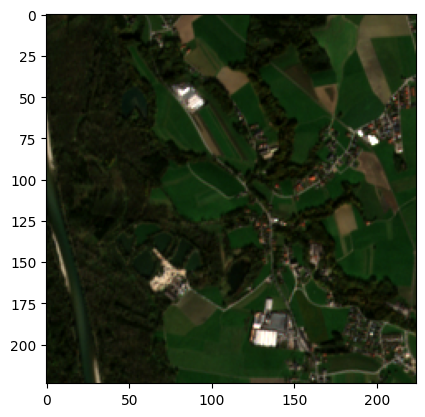

In [21]:
from matplotlib import pyplot as plt

with torch.inference_mode():
    x, y = next(iter(train_loader))
    x.size()
    gain = 1.5
    rgb = x[0, ...].numpy().transpose(1, 2, 0)
    rgb = np.clip(rgb[:, :, [2, 1, 0]], 0, 1)  # Ensure in [0, 1]

plt.imshow(gain * rgb)
plt.show()

## Model
Create the model for training.

### VGG-16

In [20]:
class VGG16(pl.LightningModule):
    """
    CNN classifier for square Sentinel-2 patches.

    Assumes flat input (B, h*w*in_channels) where spatial layout is
    channels-last: the flat was produced by X.reshape(N, -1) on an
    array of shape (N, h, w, in_channels).

    patch_size: spatial size (h = w), default 3 for 3x3 patches.
    in_channels: number of spectral bands, auto-detected in Cell 15.
    """

    def __init__(
        self,
        num_classes=10,
        in_channels=10,
        patch_size=3,
        lr=3e-4,
        max_epochs=60,
        class_weights=None,
    ):
        super().__init__()
        self.lr = lr
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.num_classes = num_classes
        self.max_epochs = max_epochs

        self.features = nn.Sequential(
            # conv1: keep spatial size (3x3 → 3x3)
            nn.Conv2d(in_channels, 64, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(25088, 4096),
            nn.ReLU(),
            nn.Linear(4096, 1000),
            nn.ReLU(),
            nn.Linear(1000, 1000),
            nn.ReLU(),
            nn.Linear(1000, num_classes),
        )

        if class_weights is not None:
            self.register_buffer("class_weights", class_weights.float())
        else:
            self.class_weights = None

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

    def _loss(self, logits, y):
        return F.cross_entropy(logits, y, weight=self.class_weights)

    def training_step(self, batch, _):
        x, y = batch
        y = y.long()
        logits = self(x)
        loss = self._loss(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        y = y.long()
        logits = self(x)
        loss = self._loss(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        return loss

    def test_step(self, batch, _):
        x, y = batch
        y = y.long()
        logits = self(x)
        loss = self._loss(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.max_epochs)
        return {"optimizer": opt, "lr_scheduler": sched}

In [21]:
model = VGG16(
    lr=config["training"]["lr"],
    num_classes=len(filtered_dataset.unique_labels),
    in_channels=config["model"]["in_channels"],
    patch_size=config["model"]["patch_size"],
    max_epochs=config["training"]["epochs"],
)
print(model)

VGG16(
  (features): Sequential(
    (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=

### ViT

In [22]:
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning.pytorch as pl
"""


class TransformerModel(pl.LightningModule):
    """
    Transformer encoder classifier for land cover classification.

    Input per sample (bands_dim and seq_len are configurable):
      - flattened: (B, seq_len * bands_dim)
      - token:     (B, seq_len, bands_dim)
      - patch:     (B, h, w, bands_dim)  where h*w == seq_len

    Defaults: 3x3 patch, 10 Sentinel-2 bands → seq_len=9, bands_dim=10.
    """

    def __init__(
        self,
        num_classes: int = 10,
        bands_dim: int = 10,
        seq_len: int = 9,
        d_model: int = 64,
        nhead: int = 8,
        num_layers: int = 4,
        dim_feedforward: int = 256,
        lr: float = 1e-3,
        max_epochs: int = 60,
        class_weights=None,
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["class_weights"])

        self.num_classes = num_classes
        self.bands_dim = bands_dim
        self.seq_len = seq_len
        self.d_model = d_model
        self.lr = lr
        self.max_epochs = max_epochs

        if class_weights is not None:
            self.register_buffer("class_weights", class_weights.float())
        else:
            self.class_weights = None

        # Project bands_dim -> d_model
        self.input_proj = nn.Linear(bands_dim, d_model)

        # Encoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # Classifier head
        self.classifier = nn.Linear(d_model, num_classes)

    def _to_tokens(self, x: torch.Tensor) -> torch.Tensor:
        """Convert x to (B, seq_len, bands_dim)."""
        if x.dim() == 2:  # (B, seq_len * bands_dim)
            x = x.view(x.size(0), self.seq_len, self.bands_dim)
        elif x.dim() == 4:  # (B, h, w, bands_dim) or (B, bands_dim, h, w)
            x = x.view(x.size(0), self.seq_len, self.bands_dim)
        elif x.dim() == 3:  # already (B, seq_len, bands_dim)
            pass
        else:
            raise ValueError(f"Unexpected x shape: {tuple(x.shape)}")
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.to(torch.float32)
        x = self._to_tokens(x)  # (B, seq_len, bands_dim)
        x = self.input_proj(x)  # (B, seq_len, d_model)
        x = self.encoder(x)  # (B, seq_len, d_model)
        x = x.mean(dim=1)  # (B, d_model)  — mean pooling
        return self.classifier(x)  # (B, num_classes)

    def _loss(self, logits, y):
        return F.cross_entropy(logits, y, weight=self.class_weights)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y.long()
        logits = self(x)
        loss = self._loss(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y.long()
        logits = self(x)
        loss = self._loss(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y = y.long()
        logits = self(x)
        loss = self._loss(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.max_epochs)
        return {"optimizer": opt, "lr_scheduler": sched}

In [23]:
model = TransformerModel(
    lr=config["training"]["lr"],
    num_classes=len(filtered_dataset.unique_labels),
    bands_dim=config["model"]["in_channels"],
    seq_len=config["model"]["patch_size"] ** 2,
    max_epochs=config["training"]["epochs"],
)

print(model)

TransformerModel(
  (input_proj): Linear(in_features=4, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=64, out_features=10, bias=True)
)


/p/project1/training2600/maurogiovanni1/envs/ml_eo_course/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


### Optional Comparison Model: CNN Classifier

If your validation accuracy plateaus near the majority-class ratio, test a small CNN baseline that uses the 3x3 patch structure directly. This is often stronger than an MLP on spatial patch data.

In [28]:
train_labels = filtered_dataset.labels[train_dataset.indices]

# train_labels = train_dataset.labels
unique_labels, counts = train_labels.unique(return_counts=True)

class_weights = torch.reciprocal(counts)
weights_dict = {k.item(): v.item() for k, v in zip(unique_labels, class_weights)}
sample_weights = torch.tensor(
    [weights_dict[label.item()] for label in train_labels], dtype=torch.float64
)
num_samples = len(sample_weights)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)
"""
print(weights_dict)
train_dataset.dataset.transform = train_transform
"""
train_dataset = TransformedSubset(train_dataset, train_transform)
val_dataset = TransformedSubset(val_dataset, val_transform)
test_dataset = TransformedSubset(test_dataset, val_transform)

train_dataloader = DataLoader(
    train_dataset,
    sampler=weighted_sampler,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [22]:
print(train_labels)
print(unique_labels, counts)
print(weights_dict)

tensor([0, 0, 0,  ..., 9, 9, 9], dtype=torch.uint8)
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8) tensor([ 153,   10, 3936, 1584,   97,   28,   97,  843,  489,  121])
{0: 0.006535947788506746, 1: 0.10000000149011612, 2: 0.0002540650311857462, 3: 0.0006313131307251751, 4: 0.010309278033673763, 5: 0.0357142873108387, 6: 0.010309278033673763, 7: 0.001186239649541676, 8: 0.002044989727437496, 9: 0.00826446246355772}


In [29]:
len(train_dataloader)

230

In [83]:
# Hyperparameters
batch_size = 512
max_epochs = 60

# Choose ONE imbalance strategy (do not combine both):
# - "sampler": use WeightedRandomSampler + unweighted CE
# - "class_weights": use shuffled batches + weighted CE
imbalance_strategy = "class_weights"  # "sampler" or "class_weights"

# Derive num_classes and patch geometry from data (do NOT use max_label+1).
num_classes = len(np.unique(y_train_np))  # e.g. 10
patch_size = 3  # 3x3 pixels per patch
in_channels = X_train.shape[1] // (patch_size**2)  # auto-detect bands (4 or 10)
print(f"num_classes={num_classes}, patch_size={patch_size}, in_channels={in_channels}")

# --- Class weights with sqrt softening ---
# Pure inverse-frequency gives extreme weights (e.g. 200x) to tiny classes,
# causing the model to spam them while ignoring medium-sized ones.
# sqrt(inv_freq) is a standard compromise: still upweights minorities but
# doesn't over-amplify very rare classes.
raw_weights = np.zeros(num_classes, dtype=np.float64)
for c, n in zip(classes, counts):
    raw_weights[int(c)] = 1.0 / n

sqrt_weights = np.sqrt(raw_weights)
sqrt_weights /= sqrt_weights.sum() / num_classes  # normalise to mean=1
class_weights_t = torch.tensor(sqrt_weights, dtype=torch.float32)

print("\nClass weights (sqrt-scaled, mean=1):")
for i, w in enumerate(sqrt_weights):
    orig = idx_to_label[i]
    n = counts[i] if i < len(counts) else 0
    print(f"  idx {i} (CORINE {orig:2d}, n={int(counts[i]):6d}): weight={w:.3f}")

if imbalance_strategy == "sampler":
    class_weights_for_loss = None
    train_sampler = sampler
    train_shuffle = False
elif imbalance_strategy == "class_weights":
    class_weights_for_loss = class_weights_t
    train_sampler = None
    train_shuffle = True
else:
    raise ValueError("imbalance_strategy must be 'sampler' or 'class_weights'")

# Pick model: "transformer", "cnn", or "mlp"
model_name = "transformer"

if model_name == "transformer":
    model = TransformerModel(
        lr=1e-3,
        num_classes=num_classes,
        bands_dim=in_channels,
        seq_len=patch_size**2,
        class_weights=class_weights_for_loss,
        max_epochs=max_epochs,
    )
elif model_name == "cnn":
    model = ConvNet(
        lr=3e-4,
        num_classes=num_classes,
        in_channels=in_channels,
        patch_size=patch_size,
        class_weights=class_weights_for_loss,
        max_epochs=max_epochs,
    )
elif model_name == "vgg":
    model = VGG16(
        lr=3e-4,
        num_classes=num_classes,
        in_channels=in_channels,
        patch_size=patch_size,
        class_weights=class_weights_for_loss,
        max_epochs=max_epochs,
    )
elif model_name == "mlp":
    model = MLP(
        in_dim=X_train.shape[1],
        num_classes=num_classes,
        lr=1e-3,
        class_weights=class_weights_for_loss,
        max_epochs=max_epochs,
    )
else:
    raise ValueError("model_name must be one of: 'transformer', 'cnn', 'mlp'")

# Create datasets
train_dataset = YourCustomDataset(X_train, y_train)
val_dataset = YourCustomDataset(X_val, y_val)
test_dataset = YourCustomDataset(X_test, y_test)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    shuffle=train_shuffle,
    num_workers=2,
    pin_memory=True,
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
print(f"\nSelected model: {model_name}")
print(f"Imbalance strategy: {imbalance_strategy}")
print(f"Training batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")

num_classes=12, patch_size=3, in_channels=0


IndexError: index 14 is out of bounds for axis 0 with size 12

## Training with PyTorch Lightning

### Callbacks

[https://lightning.ai/docs/pytorch/stable/extensions/callbacks.html](https://lightning.ai/docs/pytorch/stable/extensions/callbacks.html)

In [22]:
# Train on single GPU (for testing/development)

# from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, RichProgressBar

trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    # strategy="ddp_notebook",
    max_epochs=config["training"]["epochs"],  # Use fewer epochs for testing
    #    gradient_clip_val=1.0,
    log_every_n_steps=1,
    # callbacks=[
    # EarlyStopping(monitor="val_acc", mode="min"),
    # RichProgressBar(),
    # ModelCheckpoint(
    #     monitor="val_acc",
    #     mode="max",
    #     dirpath=DATA_ROOT / "training_logs",
    #     filename='{epoch}-{val_loss:.2f}-{val_acc:.2f}'
    #  )
    # ]
    # overfit_batches=1
)

# trainer.fit(model, train_dataloader, val_dataloader)
# trainer.test(model,test_dataloader)

trainer.fit(model, datamodule)
trainer.test(model, datamodule)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]

  | Name       | Type       | Params | Mode 
--------------------------------------------------
0 | features   | Sequential | 14.7 M | train
1 | classifier | Sequential | 107 M  | train
--------------------------------------------------
122 M     Trainable params
0         Non-trainable params
122 M     Total params
490.351   Total e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Using weighted random sampling with class weights: {0: 0.005780346691608429, 1: 0.10000000149011612, 2: 0.0002258355962112546, 3: 0.0005611672531813383, 4: 0.00917431153357029, 5: 0.03125, 6: 0.00917431153357029, 7: 0.0010537407360970974, 8: 0.0018214936135336757, 9: 0.007299270015209913}


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]
SLURM auto-requeueing enabled. Setting signal handlers.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9164835214614868     │
│         test_loss         │    0.4306797683238983     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.4306797683238983, 'test_acc': 0.9164835214614868}]

### Imbalance-aware validation diagnostics

Accuracy alone can be misleading on imbalanced labels. This cell reports:
- majority-class baseline
- balanced accuracy (mean recall across classes)
- macro-F1 (equal weight per class)
- per-class recall

In [23]:
import numpy as np
import torch


def _collect_preds_targets(model, dataloader):
    model.eval()
    device = next(model.parameters()).device
    preds_all = []
    targets_all = []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            targets = yb.detach().cpu().numpy()
            preds_all.append(preds)
            targets_all.append(targets)
    y_pred = np.concatenate(preds_all).astype(np.int64)
    y_true = np.concatenate(targets_all).astype(np.int64)
    return y_true, y_pred


def _confusion_matrix(y_true, y_pred):
    labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_idx = {int(lbl): i for i, lbl in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[int(t)], label_to_idx[int(p)]] += 1
    return labels, cm


def _imbalanced_metrics_from_cm(cm):
    tp = np.diag(cm).astype(np.float64)
    support = cm.sum(axis=1).astype(np.float64)
    pred_count = cm.sum(axis=0).astype(np.float64)

    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    precision = np.divide(tp, pred_count, out=np.zeros_like(tp), where=pred_count > 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) > 0,
    )

    balanced_acc = recall.mean()
    macro_f1 = f1.mean()
    overall_acc = tp.sum() / cm.sum() if cm.sum() > 0 else 0.0
    return overall_acc, balanced_acc, macro_f1, recall, precision, f1


# Evaluate on validation set
y_true_val, y_pred_val = _collect_preds_targets(model, datamodule.val_dataloader())
labels, cm = _confusion_matrix(y_true_val, y_pred_val)
overall_acc, balanced_acc, macro_f1, recall, precision, f1 = (
    _imbalanced_metrics_from_cm(cm)
)

vals, cnts = np.unique(y_true_val, return_counts=True)
majority_baseline = cnts.max() / cnts.sum()

pred_vals, pred_cnts = np.unique(y_pred_val, return_counts=True)
pred_order = np.argsort(pred_cnts)[::-1]

print("Validation diagnostics")
print("-" * 60)
print(f"Majority-class baseline acc: {majority_baseline:.4f}")
print(f"Overall accuracy:            {overall_acc:.4f}")
print(f"Balanced accuracy:           {balanced_acc:.4f}")
print(f"Macro-F1:                    {macro_f1:.4f}")

print("\nPredicted class distribution (top 10):")
for cls, c in zip(pred_vals[pred_order][:10], pred_cnts[pred_order][:10]):
    print(f"  class {int(cls):3d}: {int(c)}")

print("\nPer-class metrics:")
print("class | support | recall | precision | f1")
for i, cls in enumerate(labels):
    sup = int(cm[i].sum())
    print(
        f"{int(cls):5d} | {sup:7d} | {recall[i]:6.3f} | {precision[i]:9.3f} | {f1[i]:5.3f}"
    )

print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

Validation diagnostics
------------------------------------------------------------
Majority-class baseline acc: 0.5385
Overall accuracy:            0.9231
Balanced accuracy:           0.8338
Macro-F1:                    0.8376

Predicted class distribution (top 10):
  class   2: 255
  class   3: 94
  class   7: 48
  class   8: 30
  class   0: 9
  class   9: 7
  class   4: 6
  class   6: 5
  class   1: 1

Per-class metrics:
class | support | recall | precision | f1
    0 |       9 |  1.000 |     1.000 | 1.000
    1 |       1 |  1.000 |     1.000 | 1.000
    2 |     245 |  0.971 |     0.933 | 0.952
    3 |      99 |  0.848 |     0.894 | 0.870
    4 |       6 |  1.000 |     1.000 | 1.000
    5 |       1 |  0.000 |     0.000 | 0.000
    6 |       5 |  0.800 |     0.800 | 0.800
    7 |      52 |  0.885 |     0.958 | 0.920
    8 |      30 |  0.833 |     0.833 | 0.833
    9 |       7 |  1.000 |     1.000 | 1.000

Confusion matrix (rows=true, cols=pred):
[[  9   0   0   0   0   0   0   0   0 

In [24]:
def majority_baseline(y, name):
    vals, cnts = np.unique(y, return_counts=True)
    p = cnts.max() / cnts.sum()
    v = vals[np.argmax(cnts)]
    print(f"{name}: n={len(y)} classes={len(vals)}")
    print(f"  majority label={v}, proportion={p:.3f}")
    print(f"  top-5:", sorted(zip(vals, cnts), key=lambda x: -x[1])[:5])


majority_baseline(train_dataset.labels, "train")
majority_baseline(val_dataset.labels, "val")
majority_baseline(test_dataset.labels, "test")

NameError: name 'train_dataset' is not defined

## Summary

This notebook demonstrated:

1. **Transformer Architecture**: Built a multi-layer transformer with self-attention for remote sensing classification
2. **CNN Architecture**: Built a VGG-16 network for remote sensing classification
3. **PyTorch Lightning**: Simplified training code by separating data, model, and training logic using dedicate PyTorch-Lightning classes.
4. **Data Pipeline**: Custom Dataset, Subset, DataLoader, and DataModule for clean handling of data.

The trained model can classify remote sensing data into 10 land cover categories using transformer-based deep learning.

## Further reading

- **Lightning datamodules**: [Docs](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) | [Code](https://github.com/Lightning-AI/pytorch-lightning/blob/master/src/lightning/pytorch/core/datamodule.py)
- **VGG architecture**: [Paper](https://arxiv.org/abs/1409.1556) | [Code](https://docs.pytorch.org/vision/main/_modules/torchvision/models/vgg.html#VGG16_Weights)
- **Early stopping**: [Article](https://www.geeksforgeeks.org/machine-learning/regularization-by-early-stopping/)